---
Phase 5-Transformer-1: Transformer 完整解剖
---

"Attention Is All You Need" (Vaswani et al., 2017)
— 改變整個 AI 領域的一篇論文

核心想法：完全拋棄 RNN，只用 Attention

本檔涵蓋：
  1. Positional Encoding — 給序列加入位置資訊
  2. Multi-Head Self-Attention — 多角度看序列
  3. Feed-Forward Network (FFN)
  4. Layer Normalization + Residual Connection
  5. 完整的 Transformer Block
  6. Encoder vs Decoder

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

# ============================================================================
# 1. Positional Encoding
# ============================================================================

/home/acer/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


1. Positional Encoding — 告訴模型位置資訊

Self-Attention 沒有「順序」概念：
  Attention("cat sat on") = Attention("on sat cat")
  因為 attention 只看 pair-wise 的關係，沒有位置

解法：在輸入 embedding 上「加」位置資訊

  原始論文用正弦/餘弦函數：
  PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
  PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

  為什麼用正弦？
  1. 可以表達相對位置（PE(pos+k) 可以用 PE(pos) 的線性函數表示）
  2. 值域有界 [-1, 1]，不會隨位置增大
  3. 不同維度有不同頻率 → 捕捉不同尺度的位置資訊

Positional Encoding shape: (50, 64)
位置 0: [[0. 1. 0. 1. 0. 1.]...]
位置 1: [[0.841 0.54  0.682 0.732 0.533 0.846]...]


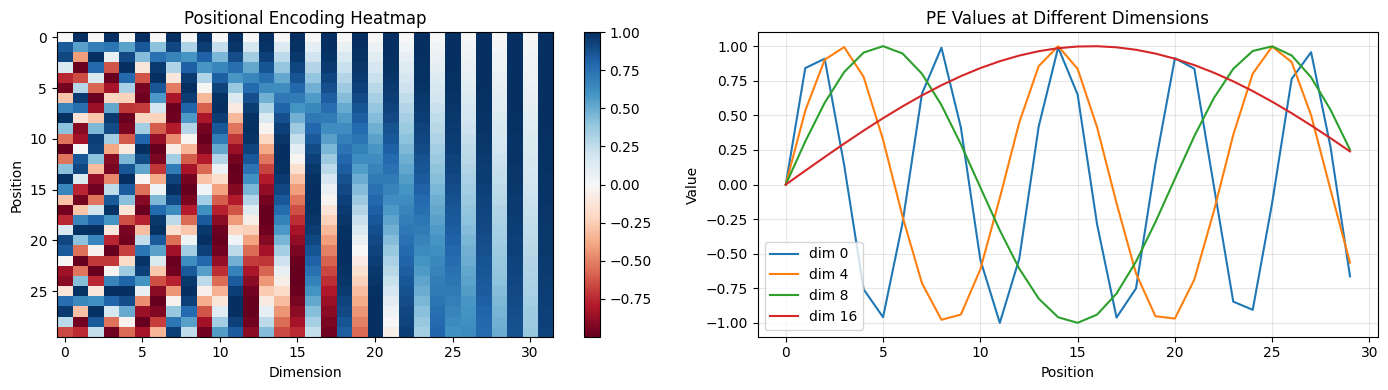

→ 圖表儲存至 transformer/plots/01_positional_encoding.png


In [2]:
print("=" * 60)
print("1. Positional Encoding — 告訴模型位置資訊")
print("=" * 60)

print("""
Self-Attention 沒有「順序」概念：
  Attention("cat sat on") = Attention("on sat cat")
  因為 attention 只看 pair-wise 的關係，沒有位置

解法：在輸入 embedding 上「加」位置資訊

  原始論文用正弦/餘弦函數：
  PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
  PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

  為什麼用正弦？
  1. 可以表達相對位置（PE(pos+k) 可以用 PE(pos) 的線性函數表示）
  2. 值域有界 [-1, 1]，不會隨位置增大
  3. 不同維度有不同頻率 → 捕捉不同尺度的位置資訊
""")


def positional_encoding_numpy(max_len, d_model):
    """NumPy 手刻 Positional Encoding"""
    pe = np.zeros((max_len, d_model))
    position = np.arange(max_len)[:, np.newaxis]     # (max_len, 1)
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    pe[:, 0::2] = np.sin(position * div_term)   # 偶數維
    pe[:, 1::2] = np.cos(position * div_term)   # 奇數維
    return pe


pe = positional_encoding_numpy(50, 64)
print(f"Positional Encoding shape: {pe.shape}")
print(f"位置 0: [{pe[0, :6].round(3)}...]")
print(f"位置 1: [{pe[1, :6].round(3)}...]")

# 視覺化
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# PE 的熱力圖
im = axes[0].imshow(pe[:30, :32], cmap='RdBu', aspect='auto')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Position')
axes[0].set_title('Positional Encoding Heatmap')
plt.colorbar(im, ax=axes[0])

# 幾個維度的正弦波
for dim in [0, 4, 8, 16]:
    axes[1].plot(pe[:30, dim], label=f'dim {dim}')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Value')
axes[1].set_title('PE Values at Different Dimensions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase-5-modern/transformer/plots/01_positional_encoding.png', dpi=100)
plt.show()
print("→ 圖表儲存至 transformer/plots/01_positional_encoding.png")


# PyTorch 版本
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """x: (batch, seq_len, d_model)"""
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

## 2. Multi-Head Self-Attention

In [3]:
print("\n" + "=" * 60)
print("2. Multi-Head Self-Attention")
print("=" * 60)

print("""
單一 Attention head 只能學一種模式
Multi-Head: 用 h 個 head，每個學不同的模式

  d_model = 512, num_heads = 8
  → 每個 head 處理 d_k = 512/8 = 64 維

  步驟：
  1. 輸入 X → 投影成 h 組 (Q, K, V)
  2. 每個 head 獨立做 Attention
  3. 把 h 個 head 的結果拼接
  4. 再做一次線性投影

  每個 head 可能學到：
  - Head 1: 語法關係（主詞-動詞）
  - Head 2: 指代關係（代名詞-名詞）
  - Head 3: 相鄰詞的關係
""")


class MultiHeadAttention(nn.Module):
    """從零實作 Multi-Head Attention"""
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        # 1. 線性投影 + 拆成多個 head
        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        # shape: (batch, num_heads, seq_len, d_k)

        # 2. Scaled Dot-Product Attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        weights = F.softmax(scores, dim=-1)

        # 3. 加權求和
        attn_output = torch.matmul(weights, V)
        # (batch, num_heads, seq_len, d_k)

        # 4. 拼接 + 最終投影
        attn_output = attn_output.transpose(1, 2).contiguous().view(
            batch_size, -1, self.d_model
        )
        output = self.W_o(attn_output)

        return output, weights


# 測試
mha = MultiHeadAttention(d_model=32, num_heads=4)
x = torch.randn(2, 8, 32)   # batch=2, seq=8, d=32
out, weights = mha(x, x, x)  # self-attention

print(f"Multi-Head Attention:")
print(f"  輸入: {x.shape}")
print(f"  輸出: {out.shape}")
print(f"  Attention weights: {weights.shape}")
print(f"  → {weights.shape[1]} 個 head，每個有 {weights.shape[2]}×{weights.shape[3]} 的 attention matrix")


2. Multi-Head Self-Attention

單一 Attention head 只能學一種模式
Multi-Head: 用 h 個 head，每個學不同的模式

  d_model = 512, num_heads = 8
  → 每個 head 處理 d_k = 512/8 = 64 維

  步驟：
  1. 輸入 X → 投影成 h 組 (Q, K, V)
  2. 每個 head 獨立做 Attention
  3. 把 h 個 head 的結果拼接
  4. 再做一次線性投影

  每個 head 可能學到：
  - Head 1: 語法關係（主詞-動詞）
  - Head 2: 指代關係（代名詞-名詞）
  - Head 3: 相鄰詞的關係

Multi-Head Attention:
  輸入: torch.Size([2, 8, 32])
  輸出: torch.Size([2, 8, 32])
  Attention weights: torch.Size([2, 4, 8, 8])
  → 4 個 head，每個有 8×8 的 attention matrix


## 3. Feed-Forward Network (FFN)

In [4]:
print("\n" + "=" * 60)
print("3. Feed-Forward Network")
print("=" * 60)

print("""
Attention 之後接一個 FFN：
  FFN(x) = Linear(GELU(Linear(x)))

  通常 FFN 的中間維度是 d_model × 4
  d_model=512 → FFN 中間層=2048

  作用：
  - Attention 處理「詞與詞的關係」
  - FFN 處理「每個位置的特徵轉換」
  - 可以看成是 1×1 卷積
""")


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None, dropout=0.1):
        super().__init__()
        if d_ff is None:
            d_ff = d_model * 4
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


ff = FeedForward(d_model=32)
x = torch.randn(2, 8, 32)
print(f"FFN: {x.shape} → {ff(x).shape}")
print(f"FFN 參數量: {sum(p.numel() for p in ff.parameters()):,}")


3. Feed-Forward Network

Attention 之後接一個 FFN：
  FFN(x) = Linear(GELU(Linear(x)))

  通常 FFN 的中間維度是 d_model × 4
  d_model=512 → FFN 中間層=2048

  作用：
  - Attention 處理「詞與詞的關係」
  - FFN 處理「每個位置的特徵轉換」
  - 可以看成是 1×1 卷積

FFN: torch.Size([2, 8, 32]) → torch.Size([2, 8, 32])
FFN 參數量: 8,352


## 4. Transformer Block

In [5]:
print("\n" + "=" * 60)
print("4. Transformer Block — 把所有元件組合")
print("=" * 60)

print("""
一個 Transformer Block:
  x → LayerNorm → Multi-Head Attention → (+x) → LayerNorm → FFN → (+x)
                                          ↑ residual                ↑ residual

  Pre-Norm (現代做法，GPT-2/LLaMA 等):
    x = x + Attention(LayerNorm(x))
    x = x + FFN(LayerNorm(x))

  Post-Norm (原始論文):
    x = LayerNorm(x + Attention(x))
    x = LayerNorm(x + FFN(x))
""")


class TransformerBlock(nn.Module):
    """Pre-Norm Transformer Block"""
    def __init__(self, d_model, num_heads, d_ff=None, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Pre-Norm + Self-Attention + Residual
        normed = self.norm1(x)
        attn_out, weights = self.attention(normed, normed, normed, mask)
        x = x + self.dropout1(attn_out)

        # Pre-Norm + FFN + Residual
        normed = self.norm2(x)
        ff_out = self.ffn(normed)
        x = x + self.dropout2(ff_out)

        return x, weights


block = TransformerBlock(d_model=32, num_heads=4)
x = torch.randn(2, 8, 32)
out, w = block(x)
print(f"Transformer Block:")
print(f"  輸入: {x.shape}")
print(f"  輸出: {out.shape}")
print(f"  參數量: {sum(p.numel() for p in block.parameters()):,}")


4. Transformer Block — 把所有元件組合

一個 Transformer Block:
  x → LayerNorm → Multi-Head Attention → (+x) → LayerNorm → FFN → (+x)
                                          ↑ residual                ↑ residual

  Pre-Norm (現代做法，GPT-2/LLaMA 等):
    x = x + Attention(LayerNorm(x))
    x = x + FFN(LayerNorm(x))

  Post-Norm (原始論文):
    x = LayerNorm(x + Attention(x))
    x = LayerNorm(x + FFN(x))

Transformer Block:
  輸入: torch.Size([2, 8, 32])
  輸出: torch.Size([2, 8, 32])
  參數量: 12,704


## 5. 完整的 Transformer Encoder

In [6]:
print("\n" + "=" * 60)
print("5. 完整的 Transformer Encoder")
print("=" * 60)


class TransformerEncoder(nn.Module):
    """完整的 Transformer Encoder（類似 BERT）"""
    def __init__(self, vocab_size, d_model, num_heads, num_layers,
                 max_len=512, num_classes=10, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)

        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, dropout=dropout)
            for _ in range(num_layers)
        ])

        self.final_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x, mask=None):
        # Embedding + Positional Encoding
        x = self.embedding(x)
        x = self.pos_encoding(x)

        # Transformer Blocks
        all_weights = []
        for layer in self.layers:
            x, w = layer(x, mask)
            all_weights.append(w)

        x = self.final_norm(x)

        # 用第一個 token 做分類（類似 BERT 的 [CLS]）
        cls_output = x[:, 0]
        logits = self.classifier(cls_output)

        return logits, all_weights


# 建立模型
model = TransformerEncoder(
    vocab_size=1000, d_model=64, num_heads=4,
    num_layers=3, num_classes=10,
)

x = torch.randint(0, 1000, (2, 20))  # batch=2, seq=20
logits, weights = model(x)

print(f"Transformer Encoder:")
print(f"  輸入: {x.shape} (token indices)")
print(f"  輸出: {logits.shape} (分類 logits)")
print(f"  Attention weights: {len(weights)} layers × {weights[0].shape}")
print(f"  參數量: {sum(p.numel() for p in model.parameters()):,}")


5. 完整的 Transformer Encoder
Transformer Encoder:
  輸入: torch.Size([2, 20]) (token indices)
  輸出: torch.Size([2, 10]) (分類 logits)
  Attention weights: 3 layers × torch.Size([2, 4, 20, 20])
  參數量: 214,730


## 6. Encoder vs Decoder 架構

In [7]:
print("\n" + "=" * 60)
print("6. 三種 Transformer 架構")
print("=" * 60)

print("""
  ┌──────────────────────────────────────────────────────┐
  │ Encoder-Only (BERT)                                   │
  │  用途：理解 / 分類                                     │
  │  特點：雙向 attention（可以看到前後文）                  │
  │  例子：BERT, RoBERTa, ELECTRA                         │
  │  任務：文字分類、NER、問答                              │
  └──────────────────────────────────────────────────────┘

  ┌──────────────────────────────────────────────────────┐
  │ Decoder-Only (GPT)                                    │
  │  用途：生成                                            │
  │  特點：causal attention（只能看到過去）                  │
  │  例子：GPT-2/3/4, LLaMA, Claude                      │
  │  任務：文字生成、對話、程式碼生成                        │
  └──────────────────────────────────────────────────────┘

  ┌──────────────────────────────────────────────────────┐
  │ Encoder-Decoder (T5)                                  │
  │  用途：序列到序列                                      │
  │  特點：encoder 雙向 + decoder causal + cross-attention│
  │  例子：T5, BART, mT5                                 │
  │  任務：翻譯、摘要                                      │
  └──────────────────────────────────────────────────────┘

  現在的趨勢：
  Decoder-Only 大一統
  GPT-4, Claude, LLaMA, Gemini 都是 Decoder-Only
  → 只要模型夠大，decoder-only 就能做幾乎所有任務

下一步：02_gpt_from_scratch.py — 從零搭建 GPT
""")


6. 三種 Transformer 架構

  ┌──────────────────────────────────────────────────────┐
  │ Encoder-Only (BERT)                                   │
  │  用途：理解 / 分類                                     │
  │  特點：雙向 attention（可以看到前後文）                  │
  │  例子：BERT, RoBERTa, ELECTRA                         │
  │  任務：文字分類、NER、問答                              │
  └──────────────────────────────────────────────────────┘

  ┌──────────────────────────────────────────────────────┐
  │ Decoder-Only (GPT)                                    │
  │  用途：生成                                            │
  │  特點：causal attention（只能看到過去）                  │
  │  例子：GPT-2/3/4, LLaMA, Claude                      │
  │  任務：文字生成、對話、程式碼生成                        │
  └──────────────────────────────────────────────────────┘

  ┌──────────────────────────────────────────────────────┐
  │ Encoder-Decoder (T5)                                  │
  │  用途：序列到序列                                      │
  │  特點：encoder 雙向 + deco